In [2]:
!pip install -q umap-learn thop

**Imports and seed**

In [3]:
import os
import re
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import umap
from thop import profile

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

2026-04-04 16:38:32.101791: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775320712.327965      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775320712.389658      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775320712.891961      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775320712.892006      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775320712.892009      55 computation_placer.cc:177] computation placer alr

Device: cuda


**Config**

In [4]:
CONFIG = {
    "img_size": 224,
    "batch_size_ssl": 64,
    "batch_size_eval": 64,
    "epochs_ssl": 100,
    "lr_ssl": 3e-4,
    "weight_decay": 1e-4,
    "temperature": 0.5,
    "num_workers": 2,
    "train_ratio": 0.8,              
    "val_ratio_inside_train": 0.1,   
    "save_dir": "/kaggle/working/simclr_outputs",
}
os.makedirs(CONFIG["save_dir"], exist_ok=True)


DATA_ROOT = "/kaggle/input/datasets/diptadasopu/processed-rice-varieties/PRBD Microscopic Image of Different Processed Rice"

print("DATA_ROOT exists:", os.path.exists(DATA_ROOT))
print("Folders inside root:", os.listdir(DATA_ROOT) if os.path.exists(DATA_ROOT) else "Path not found")

DATA_ROOT exists: True
Folders inside root: ['Original_Images', 'Augmented_images']


**Build dataframe from Original + Augmented**

In [5]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def is_image_file(path):
    return os.path.splitext(path)[1].lower() in VALID_EXTS

def infer_group_id(filepath):
    name = os.path.splitext(os.path.basename(filepath))[0].lower()

    patterns = [
        r'(_aug_\d+)$',
        r'(_aug\d+)$',
        r'(_flip)$',
        r'(_hflip)$',
        r'(_vflip)$',
        r'(_rot_\d+)$',
        r'(_rot\d+)$',
        r'(_rotate_\d+)$',
        r'(_rotate\d+)$',
        r'(_blur)$',
        r'(_jitter)$',
        r'(_crop)$',
        r'(_noise)$',
        r'(_sharp)$',
        r'(_contrast)$',
        r'(_brightness)$',
    ]

    base = name
    for p in patterns:
        base = re.sub(p, '', base)

    return base

def build_dataframe(data_root):
    rows = []

    target_folders = ["Original_Images", "Augmented_images"]

    for folder_name in target_folders:
        folder_path = os.path.join(data_root, folder_name)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found")
            continue

        
        class_dirs = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        class_dirs = sorted(class_dirs)

        for cls_name in class_dirs:
            cls_dir = os.path.join(folder_path, cls_name)
            for root, _, files in os.walk(cls_dir):
                for f in files:
                    path = os.path.join(root, f)
                    if is_image_file(path):
                        rows.append({
                            "filepath": path,
                            "class_name": cls_name,
                            "source_folder": folder_name,
                            "group_id": infer_group_id(path),
                        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError("No images found. Check DATA_ROOT and folder structure.")

    classes = sorted(df["class_name"].unique())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    df["label"] = df["class_name"].map(class_to_idx)

    return df, classes, class_to_idx

df, classes, class_to_idx = build_dataframe(DATA_ROOT)

print("Total images:", len(df))
print("Classes:", classes)
print(df.head())
print(df["source_folder"].value_counts())

Total images: 10000
Classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']
                                            filepath class_name  \
0  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
1  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
2  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
3  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
4  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   

     source_folder                  group_id  label  
0  Original_Images  processed_s20250325_0155      0  
1  Original_Images  processed_s20250325_0037      0  
2  Original_Images  processed_s20250325_0215      0  
3  Original_Images  processed_s20250325_0099      0  
4  Original_Images  processed_s20250325_0132      0  
source_folder
Augmented_images    8000
Original_Images     2000
Name: count, dtype: int64


**Check filenames and group ids**

In [6]:
sample_df = df.sample(min(20, len(df)), random_state=SEED)[["filepath", "group_id", "class_name", "source_folder"]]
sample_df

,filepath,group_id,class_name,source_folder
6252,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0017,Ghee Bhog,Augmented_images
4684,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0055,Beroi,Augmented_images
1731,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250423_0003,Miniket,Original_Images
4742,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0006,Beroi,Augmented_images
4521,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0040,Beroi,Augmented_images
6340,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0038,Ghee Bhog,Augmented_images
576,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0141,BR-29,Original_Images
5202,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250423_0132,Chinigura,Augmented_images
6363,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0027,Ghee Bhog,Augmented_images
439,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0152,BR-29,Original_Images


**Grouped split (leakage protection)**

In [7]:
def grouped_train_test_val_split(df, train_ratio=0.8, val_ratio_inside_train=0.1, random_state=42):
    groups = df["group_id"].values
    y = df["label"].values

    gss = GroupShuffleSplit(n_splits=1, train_size=train_ratio, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, y, groups=groups))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

    groups_train = train_df["group_id"].values
    y_train = train_df["label"].values

    train_ratio_inside = 1.0 - val_ratio_inside_train
    gss2 = GroupShuffleSplit(n_splits=1, train_size=train_ratio_inside, random_state=random_state)
    tr_idx, val_idx = next(gss2.split(train_df, y_train, groups=groups_train))

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    val_df = train_df.iloc[val_idx].reset_index(drop=True)

    return tr_df, val_df, test_df

train_df, val_df, test_df = grouped_train_test_val_split(
    df,
    train_ratio=CONFIG["train_ratio"],
    val_ratio_inside_train=CONFIG["val_ratio_inside_train"],
    random_state=SEED,
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("Overlap train-val :", len(set(train_df.group_id) & set(val_df.group_id)))
print("Overlap train-test:", len(set(train_df.group_id) & set(test_df.group_id)))
print("Overlap val-test  :", len(set(val_df.group_id) & set(test_df.group_id)))

Train: 7225
Val  : 790
Test : 1985
Overlap train-val : 0
Overlap train-test: 0
Overlap val-test  : 0


**Transforms**

In [8]:
class SimCLRTransform:
    def __init__(self, size=224):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size=size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
            ], p=0.8),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))
            ], p=0.3),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, x):
        x1 = self.transform(x)
        x2 = self.transform(x)
        return x1, x2

basic_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

**Datasets and loaders**

In [9]:
class SSLDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        x1, x2 = self.transform(img)
        return x1, x2

class LabeledDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        x = self.transform(img)
        y = int(row["label"])
        return x, y

ssl_train_dataset = SSLDataset(train_df, SimCLRTransform(size=CONFIG["img_size"]))
probe_train_dataset = LabeledDataset(train_df, basic_transform)
probe_val_dataset   = LabeledDataset(val_df, basic_transform)
probe_test_dataset  = LabeledDataset(test_df, basic_transform)

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=CONFIG["batch_size_ssl"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    drop_last=True,
)

probe_train_loader = DataLoader(probe_train_dataset, batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
probe_val_loader   = DataLoader(probe_val_dataset,   batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
probe_test_loader  = DataLoader(probe_test_dataset,  batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print("SSL train batches:", len(ssl_train_loader))
print("Probe train size :", len(probe_train_dataset))
print("Probe val size   :", len(probe_val_dataset))
print("Probe test size  :", len(probe_test_dataset))

SSL train batches: 112
Probe train size : 7225
Probe val size   : 790
Probe test size  : 1985


**SimCLR model**

In [10]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.encoder = backbone
        self.projector = ProjectionHead(feat_dim, hidden_dim=2048, out_dim=128)
        self.feat_dim = feat_dim

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return h, z

model = SimCLR().to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s] 


SimCLR(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (

**NT-Xent loss**

In [11]:
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z = torch.cat([z1, z2], dim=0)   # [2N, D]
    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)

    # float16 overflow avoid করার জন্য safer negative value
    sim = sim.masked_fill(mask, -1e4)

    positives = torch.cat([
        torch.diag(sim, batch_size),
        torch.diag(sim, -batch_size)
    ], dim=0)

    numerator = torch.exp(positives)
    denominator = torch.exp(sim).sum(dim=1)

    loss = -torch.log(numerator / denominator)
    return loss.mean()

**Optimizer and training setup**

In [12]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr_ssl"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["epochs_ssl"]
)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

**SSL pretraining for 100 epochs**

In [13]:
best_loss = float("inf")
history_ssl = {"epoch": [], "loss": [], "time_sec": []}

for epoch in range(1, CONFIG["epochs_ssl"] + 1):
    model.train()
    running_loss = 0.0
    start_time = time.time()

    for x1, x2 in ssl_train_loader:
        x1 = x1.to(device, non_blocking=True)
        x2 = x2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            _, z1 = model(x1)
            _, z2 = model(x2)
            loss = nt_xent_loss(z1, z2, temperature=CONFIG["temperature"])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    scheduler.step()

    epoch_loss = running_loss / len(ssl_train_loader)
    epoch_time = time.time() - start_time

    history_ssl["epoch"].append(epoch)
    history_ssl["loss"].append(epoch_loss)
    history_ssl["time_sec"].append(epoch_time)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), os.path.join(CONFIG["save_dir"], "best_simclr_model.pth"))
        torch.save(model.encoder.state_dict(), os.path.join(CONFIG["save_dir"], "best_simclr_encoder.pth"))

    print(f"Epoch [{epoch:03d}/{CONFIG['epochs_ssl']}] Loss: {epoch_loss:.4f} Time: {epoch_time:.2f}s")

print("Best SSL loss:", best_loss)

Epoch [001/100] Loss: 3.2200 Time: 93.54s
Epoch [002/100] Loss: 3.0337 Time: 83.05s
Epoch [003/100] Loss: 2.9999 Time: 82.34s
Epoch [004/100] Loss: 2.9803 Time: 80.90s
Epoch [005/100] Loss: 2.9688 Time: 81.17s
Epoch [006/100] Loss: 2.9640 Time: 79.27s
Epoch [007/100] Loss: 2.9539 Time: 81.55s
Epoch [008/100] Loss: 2.9489 Time: 82.64s
Epoch [009/100] Loss: 2.9478 Time: 83.25s
Epoch [010/100] Loss: 2.9429 Time: 81.76s
Epoch [011/100] Loss: 2.9380 Time: 81.90s
Epoch [012/100] Loss: 2.9346 Time: 82.12s
Epoch [013/100] Loss: 2.9334 Time: 81.58s
Epoch [014/100] Loss: 2.9333 Time: 80.23s
Epoch [015/100] Loss: 2.9306 Time: 79.95s
Epoch [016/100] Loss: 2.9284 Time: 81.27s
Epoch [017/100] Loss: 2.9235 Time: 81.39s
Epoch [018/100] Loss: 2.9254 Time: 82.50s
Epoch [019/100] Loss: 2.9219 Time: 82.80s
Epoch [020/100] Loss: 2.9212 Time: 83.77s
Epoch [021/100] Loss: 2.9204 Time: 83.24s
Epoch [022/100] Loss: 2.9193 Time: 80.38s
Epoch [023/100] Loss: 2.9194 Time: 82.47s
Epoch [024/100] Loss: 2.9195 Time:

**SSL loss curve**

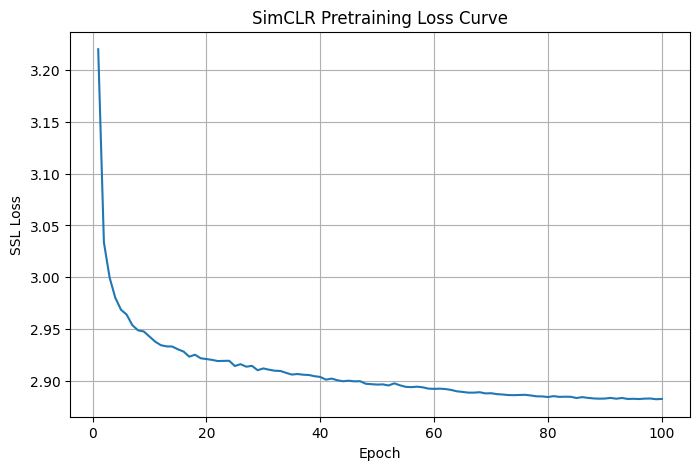

In [14]:
history_df = pd.DataFrame(history_ssl)
history_df.to_csv(os.path.join(CONFIG["save_dir"], "ssl_history.csv"), index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["loss"])
plt.xlabel("Epoch")
plt.ylabel("SSL Loss")
plt.title("SimCLR Pretraining Loss Curve")
plt.grid(True)
plt.show()

**Load best encoder**

In [15]:
model.load_state_dict(torch.load(os.path.join(CONFIG["save_dir"], "best_simclr_model.pth"), map_location=device))
encoder = model.encoder.to(device)
encoder.eval()
print("Best encoder loaded")

Best encoder loaded


**Feature extraction**

In [16]:
@torch.no_grad()
def extract_features(dataloader, encoder):
    encoder.eval()
    all_feats, all_labels = [], []

    for x, y in dataloader:
        x = x.to(device, non_blocking=True)
        feats = encoder(x)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(y.numpy())

    feats = np.concatenate(all_feats, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return feats, labels

X_train, y_train = extract_features(probe_train_loader, encoder)
X_val,   y_val   = extract_features(probe_val_loader, encoder)
X_test,  y_test  = extract_features(probe_test_loader, encoder)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (7225, 2048)
X_val  : (790, 2048)
X_test : (1985, 2048)


**Linear probe**

In [17]:
probe_clf = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs",
    random_state=SEED,
    n_jobs=-1
)

start = time.time()
probe_clf.fit(X_train, y_train)
probe_train_time = time.time() - start

y_pred = probe_clf.predict(X_test)
y_prob = probe_clf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)

y_test_bin = label_binarize(y_test, classes=list(range(len(classes))))
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")

print("===== Linear Probe Results =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("ROC-AUC   :", round(roc_auc, 4))
print("Train time:", round(probe_train_time, 2), "sec")

===== Linear Probe Results =====
Accuracy  : 0.873
Precision : 0.8776
Recall    : 0.873
F1-score  : 0.8732
ROC-AUC   : 0.989
Train time: 35.41 sec


**Classification report + per-class accuracy**

In [18]:
print(classification_report(y_test, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_test, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "class": classes,
    "per_class_accuracy": per_class_acc
})

per_class_df

               precision    recall  f1-score   support

         Aush     0.9779    0.9833    0.9806       180
        BR-28     0.6533    0.7350    0.6918       200
        BR-29     0.8063    0.8950    0.8483       200
        Beroi     0.9845    0.9795    0.9820       195
    Chinigura     0.9952    0.9952    0.9952       210
    Ghee Bhog     0.9551    0.8718    0.9115       195
 Katari Najir     0.8268    0.8970    0.8605       165
Katari Siddho     0.7617    0.7737    0.7676       190
      Miniket     0.9327    0.9455    0.9391       220
       Swarna     0.8722    0.6826    0.7659       230

     accuracy                         0.8730      1985
    macro avg     0.8766    0.8759    0.8742      1985
 weighted avg     0.8776    0.8730    0.8732      1985



,class,per_class_accuracy
0,Aush,0.983333
1,BR-28,0.735000
2,BR-29,0.895000
3,Beroi,0.979487
4,Chinigura,0.995238
5,Ghee Bhog,0.871795
6,Katari Najir,0.896970
7,Katari Siddho,0.773684
8,Miniket,0.945455
9,Swarna,0.682609


**Confusion matrix plot**

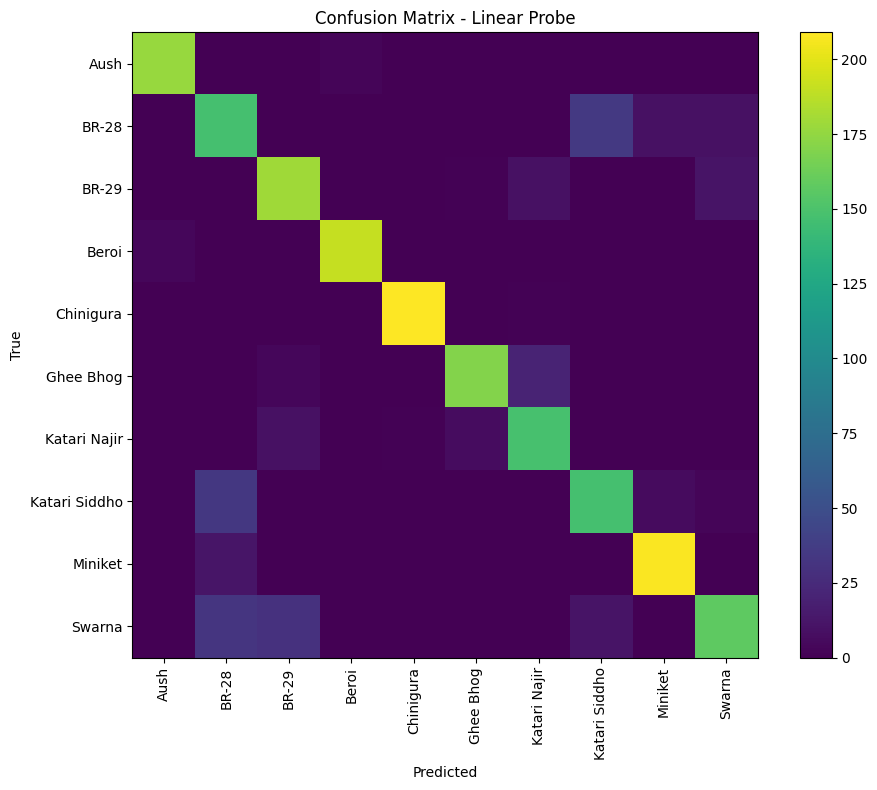

In [19]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Linear Probe")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

**ROC curves**

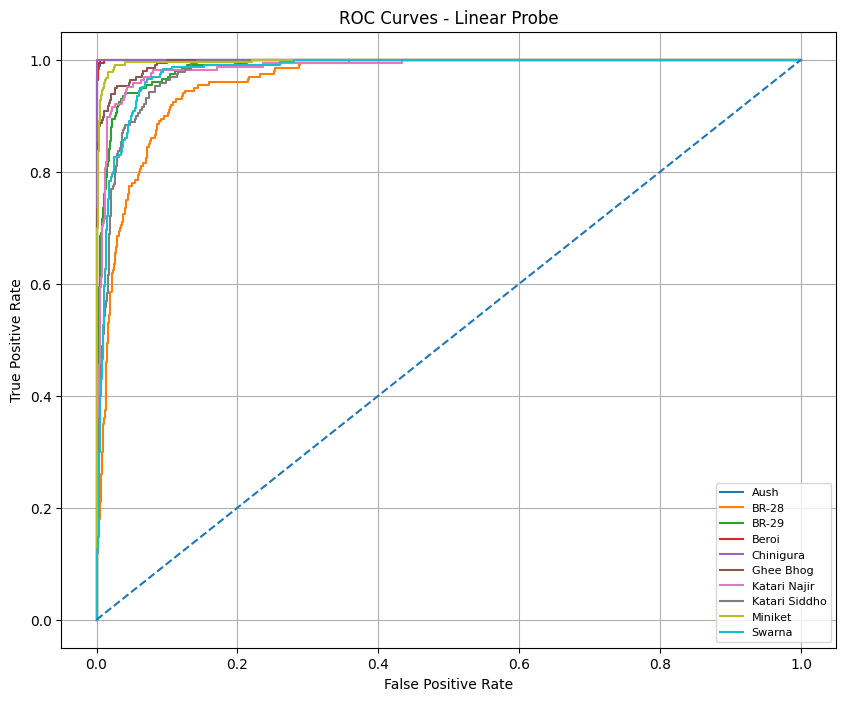

In [20]:
plt.figure(figsize=(10, 8))

for i, cls_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=cls_name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Linear Probe")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

**k-NN accuracy**

In [21]:
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_knn = knn.predict(X_test)
    acc_knn = accuracy_score(y_test, pred_knn)
    print(f"k={k} -> Accuracy: {acc_knn:.4f}")

k=1 -> Accuracy: 0.7783
k=5 -> Accuracy: 0.7955
k=20 -> Accuracy: 0.8076


**PCA, t-SNE, UMAP**

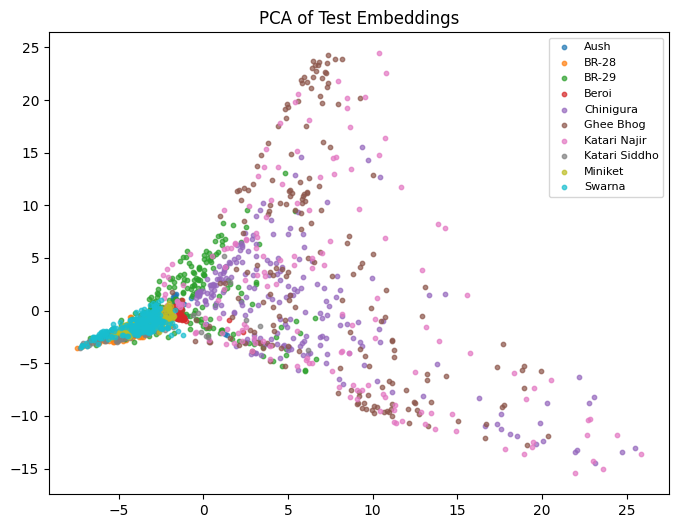

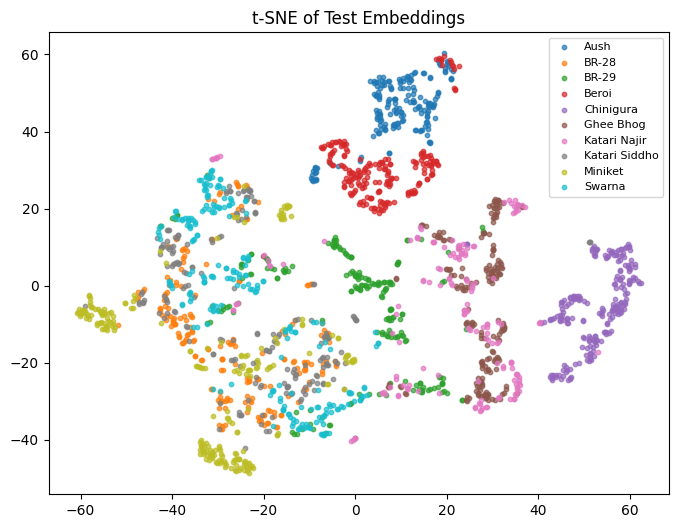

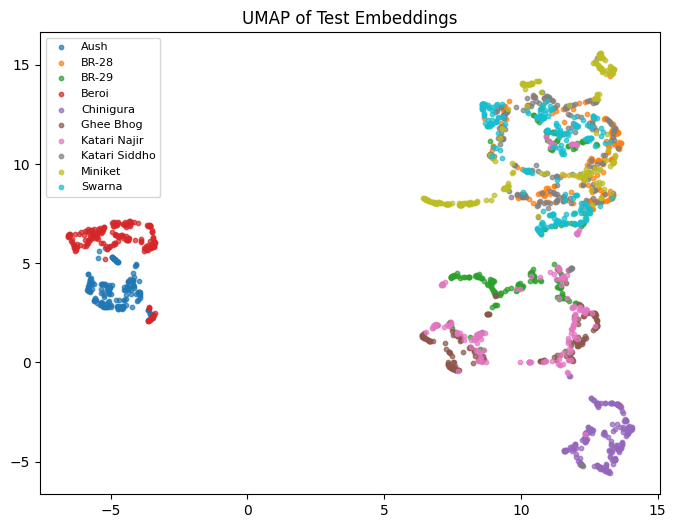

In [22]:
max_vis = 2000

if len(X_test) > max_vis:
    idx = np.random.choice(len(X_test), max_vis, replace=False)
    X_vis = X_test[idx]
    y_vis = y_test[idx]
else:
    X_vis = X_test
    y_vis = y_test

# PCA
pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(pca_2d[m, 0], pca_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("PCA of Test Embeddings")
plt.legend(fontsize=8)
plt.show()


tsne_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(tsne_2d[m, 0], tsne_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("t-SNE of Test Embeddings")
plt.legend(fontsize=8)
plt.show()


umap_2d = umap.UMAP(n_components=2, random_state=SEED).fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(umap_2d[m, 0], umap_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("UMAP of Test Embeddings")
plt.legend(fontsize=8)
plt.show()

**Silhouette score**

In [23]:
sil_score = silhouette_score(X_vis, y_vis)
print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: -0.0318


**Label efficiency curve**

In [24]:
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
label_eff_results = []

for frac in fractions:
    sampled_idx = []

    for c in np.unique(y_train):
        c_idx = np.where(y_train == c)[0]
        n_take = max(1, int(len(c_idx) * frac))
        chosen = np.random.choice(c_idx, n_take, replace=False)
        sampled_idx.extend(chosen.tolist())

    sampled_idx = np.array(sampled_idx)

    clf_frac = LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=SEED,
        n_jobs=-1
    )
    clf_frac.fit(X_train[sampled_idx], y_train[sampled_idx])
    pred_frac = clf_frac.predict(X_test)
    acc_frac = accuracy_score(y_test, pred_frac)

    label_eff_results.append({
        "fraction": frac,
        "accuracy": acc_frac,
        "n_samples": len(sampled_idx)
    })

    print(f"{int(frac*100)}% labels -> Accuracy: {acc_frac:.4f}")

label_eff_df = pd.DataFrame(label_eff_results)
label_eff_df

1% labels -> Accuracy: 0.5537
5% labels -> Accuracy: 0.7496
10% labels -> Accuracy: 0.8116
25% labels -> Accuracy: 0.8393
50% labels -> Accuracy: 0.8479


,fraction,accuracy,n_samples
0,0.01,0.553652,67
1,0.05,0.749622,357
2,0.10,0.811587,721
3,0.25,0.839295,1802
4,0.50,0.847859,3611


**Plot label efficiency**

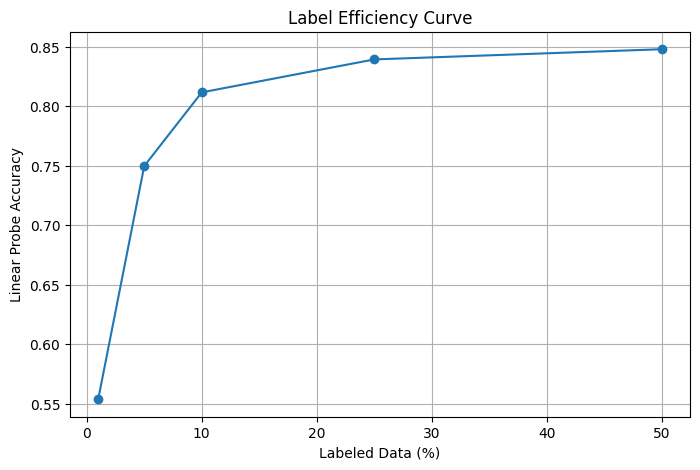

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(label_eff_df["fraction"] * 100, label_eff_df["accuracy"], marker="o")
plt.xlabel("Labeled Data (%)")
plt.ylabel("Linear Probe Accuracy")
plt.title("Label Efficiency Curve")
plt.grid(True)
plt.show()

**GFLOPs**

In [26]:
dummy = torch.randn(1, 3, CONFIG["img_size"], CONFIG["img_size"]).to(device)
macs, params = profile(encoder, inputs=(dummy,), verbose=False)
gflops = (2 * macs) / 1e9

print(f"GFLOPs per inference @ {CONFIG['img_size']}x{CONFIG['img_size']}: {gflops:.4f}")
print(f"Params: {params/1e6:.2f}M")

GFLOPs per inference @ 224x224: 8.2634
Params: 23.51M


In [27]:
summary = {
    "method": "SimCLR",
    "backbone": "ResNet50",
    "split": f"{int(CONFIG['train_ratio']*100)}:{int((1-CONFIG['train_ratio'])*100)}",
    "epochs_ssl": CONFIG["epochs_ssl"],
    "img_size": CONFIG["img_size"],
    "accuracy": acc,
    "precision_weighted": prec,
    "recall_weighted": rec,
    "f1_weighted": f1,
    "roc_auc_weighted_ovr": roc_auc,
    "linear_probe_train_time_sec": probe_train_time,
    "silhouette_score": sil_score,
    "gflops": gflops,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(CONFIG["save_dir"], "final_summary.csv"), index=False)
per_class_df.to_csv(os.path.join(CONFIG["save_dir"], "per_class_accuracy.csv"), index=False)
label_eff_df.to_csv(os.path.join(CONFIG["save_dir"], "label_efficiency.csv"), index=False)

print("Saved in:", CONFIG["save_dir"])
summary_df

Saved in: /kaggle/working/simclr_outputs


,method,backbone,split,epochs_ssl,img_size,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_weighted_ovr,linear_probe_train_time_sec,silhouette_score,gflops
0,SimCLR,ResNet50,80:19,100,224,0.873048,0.877644,0.873048,0.873216,0.988995,35.410325,-0.031786,8.263389
